<a href="https://colab.research.google.com/github/ob3x/Learn-Ds/blob/main/PCA_Projects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [85]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

np.set_printoptions(precision=4, suppress=True, edgeitems=5, linewidth=200)

In [86]:
df_raw = pd.read_csv("https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data", header=None)
df = df_raw.copy()
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [87]:
data = df.iloc[:, 1:]
target = df.iloc[:, 0]
data.head()

,1,2,3,4,5,6,7,8,9,10,11,12,13
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [88]:
target.value_counts()

,count
0,
2,71
1,59
3,48


In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (142, 13)
y_train shape: (142,)
X_test shape: (36, 13)
y_test shape: (36,)


In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)
X_train_std[:5]

array([[ 1.6653, -0.6084,  1.219 ,  1.6054, -0.1674,  0.804 , -0.6917,  1.2672,  1.8775,  3.4195, -1.6563, -0.8794, -0.2486],
       [-0.5495,  2.7515,  1.0033,  1.6054, -0.3044, -0.7854, -1.4012,  2.0496, -0.8735, -0.0248, -0.5846, -1.2546, -0.7299],
       [-0.7453, -1.1435, -0.9375, -0.2827, -0.8524,  1.937 ,  1.7468, -1.0017,  0.588 , -0.2401,  0.3585,  0.2462, -0.2486],
       [ 0.6129, -0.6172,  1.0033,  0.8792, -0.7839,  0.4893, -0.9015,  1.189 ,  1.1726,  2.8813, -1.6563, -1.1296, -0.3814],
       [ 0.1112, -0.7663, -0.9375, -1.1541, -0.1674,  0.1745,  0.6375, -0.6887, -0.4093, -0.5845,  0.9586,  0.1351,  0.9464]])

In [91]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)
X_train_pca.shape

(142, 3)

In [92]:
X_train_pca[:3]

array([[-1.166 ,  3.6153,  1.1513],
       [-3.8626,  0.4822,  1.7276],
       [ 2.2835, -1.275 , -0.1317]])

In [93]:
results = pd.DataFrame({"explained_variance_ratio" : pca.explained_variance_ratio_})
results["cumulative"] = results["explained_variance_ratio"].cumsum()
results["component"] = results.index + 1
results

,explained_variance_ratio,cumulative,component
0,0.359001,0.359001,1
1,0.186919,0.545920,2
2,0.116066,0.661986,3


In [94]:
fig = go.Figure(go.Bar(x=results["component"], y=results["explained_variance_ratio"], name="Explained Variance Ratio"))
fig.add_trace(go.Scatter(x=results["component"], y=results["cumulative"], name="Cumulative Explained Variance Ratio"))
fig.update_layout(title=f"PCA - {pca.n_components_} components", xaxis_title="Component", yaxis_title="Explained Variance Ratio", template="plotly_dark")
fig.show()

In [95]:
X_train_pca_df = pd.DataFrame(data=np.c_[X_train_pca, y_train], columns=["pca_1", "pca_2", "pca_3", "target"])
X_train_pca_df.head()

,pca_1,pca_2,pca_3,target
0,-1.166027,3.615327,1.151285,3.0
1,-3.862612,0.482177,1.727584,3.0
2,2.283538,-1.275033,-0.131677,2.0
3,-1.678507,2.496962,0.556619,3.0
4,1.572842,-0.688203,-1.417945,1.0


In [96]:
px.scatter_3d(X_train_pca_df, x="pca_1", y="pca_2", z="pca_3", color="target", template="plotly_dark")

In [97]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)


In [98]:
X_train = X_train[:5000]
X_test = X_test[:5000]

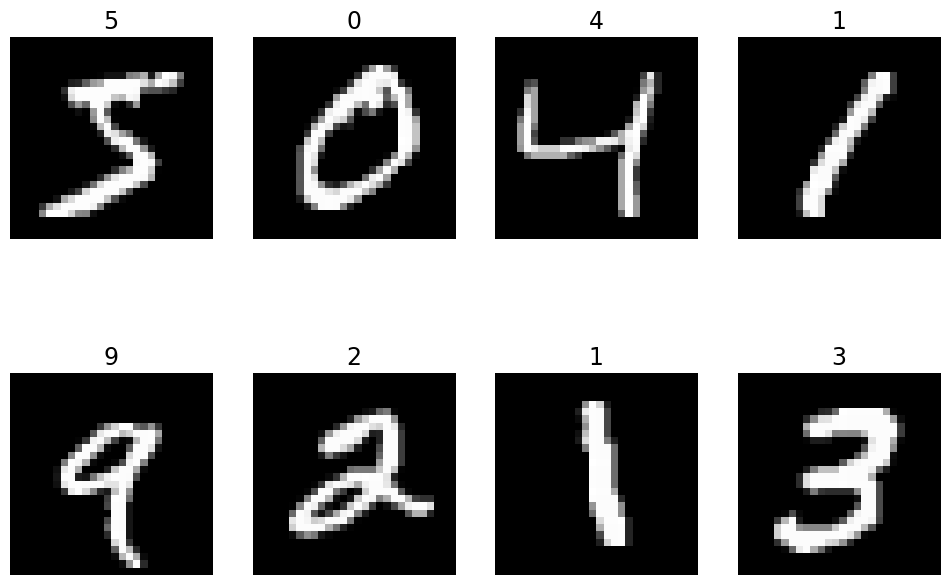

In [99]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))

for i in range(8):
  plt.subplot(240 + i + 1)
  plt.imshow(X_train[i], cmap="gray")
  plt.title(y_train[i], fontsize=17)
  plt.axis("off")

plt.show()

In [100]:
X_train.shape

(5000, 28, 28)

In [101]:
X_train = X_train.reshape(-1, 28 * 28)
X_train.shape

(5000, 784)

In [102]:
X_train = X_train / 255.0

In [103]:
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_train_pca.shape

(5000, 148)

In [104]:
results = pd.DataFrame({"explained_variance_ratio" : pca.explained_variance_ratio_})
results["cumulative"] = results["explained_variance_ratio"].cumsum()
results["component"] = results.index + 1
results

,explained_variance_ratio,cumulative,component
0,0.098676,0.098676,1
1,0.074045,0.172721,2
2,0.061277,0.233998,3
3,0.054053,0.288051,4
4,0.047376,0.335427,5
...,...,...,...
143,0.000497,0.948219,144
144,0.000491,0.948711,145
145,0.000482,0.949193,146
146,0.000473,0.949665,147


In [105]:
fig = go.Figure(go.Bar(x=results["component"], y=results["explained_variance_ratio"], name="Explained Variance Ratio"))
fig.add_trace(go.Scatter(x=results["component"], y=results["cumulative"], name="Cumulative Explained Variance Ratio"))
fig.update_layout(title=f"PCA - {pca.n_components_} components", template="plotly_dark")
fig.show()

In [106]:
X_train_pca[0].shape

(148,)

In [107]:
approx = pca.inverse_transform(X_train_pca)
approx[0].shape

(784,)

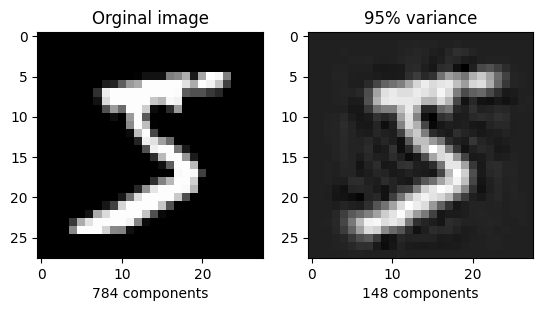

In [108]:
plt.subplot(121)
plt.imshow(X_train[0].reshape(28, 28), cmap="gray", interpolation="nearest")
plt.xlabel("784 components")
plt.title("Orginal image")

plt.subplot(122)
plt.imshow(approx[0].reshape(28, 28), cmap="gray", interpolation="nearest")
plt.xlabel(f"{pca.n_components_} components")
plt.title("95% variance")
plt.show()

In [130]:
def make_pca(n_components, data, idx=0):

  pca = PCA(n_components=n_components)
  data_pca = pca.fit_transform(data)

  approx = pca.inverse_transform(data_pca)

  plt.imshow(approx[idx].reshape(28, 28), cmap="gray_r", interpolation="nearest")
  plt.xlabel(f"{pca.n_components} components")
  plt.title(f"{str(n_components * 100)}% variance")

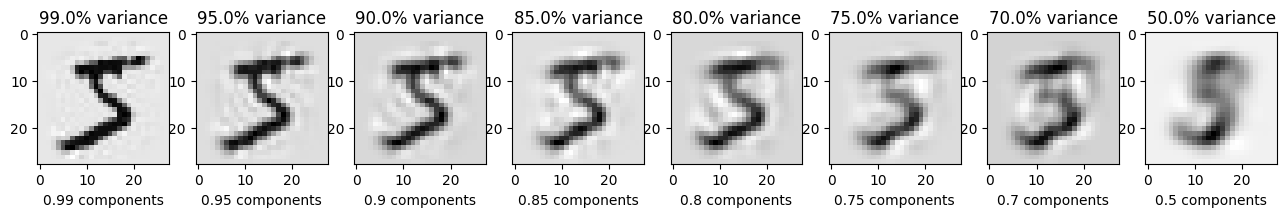

In [131]:
plt.figure(figsize=(16, 10))
for i, val in enumerate([0.99, 0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.50]):
  plt.subplot(1, 8, i + 1)
  make_pca(val, X_train)

plt.show()

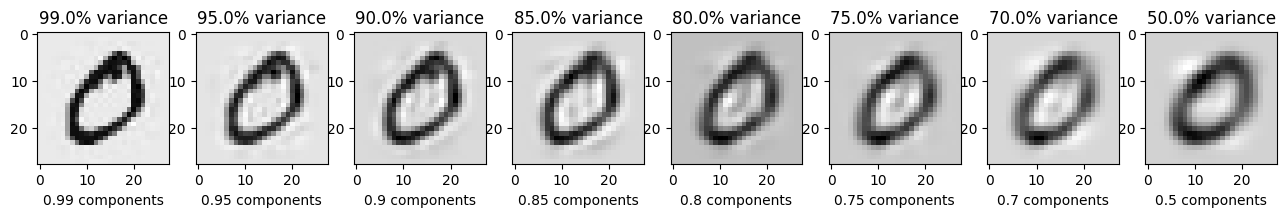

In [132]:
plt.figure(figsize=(16, 10))
for i, val in enumerate([0.99, 0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.50]):
  plt.subplot(1, 8, i + 1)
  make_pca(val, X_train, 1)

plt.show()